<a href="https://colab.research.google.com/github/mushynskaaa/sales-analysis-in-google-colab/blob/main/module_task_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Connecting to Data and Data Overview**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns


# Connecting to Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Changing the workspace folder
%cd /content/drive/MyDrive/Mate_Academy/Jupyter_Notebook

/content/drive/MyDrive/Mate_Academy/Jupyter_Notebook


In [ ]:
# Import CSV file "countries"
countries = pd.read_csv("countries.csv")
# Display first 5 rows of the "countries" Table
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


###**Column data description**
**Table** **"Countries"**

  - ***name*** - country name
  - ***alpha-2*** - wo-letter country code
  - ***alpha-3*** - three-letter country code (foreign key to join with the "Events" table)
  - ***region*** - region name
  - ***sub-region*** - sub-region name

In [ ]:
# import CSV file "events"
events = pd.read_csv("events.csv",  keep_default_na=False, na_values=[''])
# Display first 5 rows of the "events" Table
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,#N/A,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


###**Column data description**
**Table** **"Events"**

  - ***Order ID*** - unique identifier for the order
  - ***Order Date*** - date the order was placed in mm/dd/yyyy format
  - ***Ship Date*** - order shipping date
  - ***Order Priority*** - order's priority level
  - ***Country Code*** - three-letter country code (foreign key to join with the "countries" table)
  - ***Product ID*** - product identifier (foreign key to join with the "products" table)
  - ***Sales Channel*** - method used by the customer to place the order: "online" (via website or app) or "offline" (purchase at a physical retail store)
  - ***Units Sold*** - quantity of items sold
  - ***Unit Price*** - price per single unit for the customer
  - ***Unit Cost*** - cost per single unit for the business (cost of goods sold)

In [ ]:
# import CSV file "products"
products = pd.read_csv("products.csv")
# Display first 5 rows of the "Products" Table
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


###**Column data description**
**Table** **"Products"**

  - ***id*** - product identifier (foreign key to join with the "Events" table)
  - ***item_type*** - product category

###**Keys for table joins**
  - **"Events"** table and **"Countries"** table
    - **Relationship:** by country code.
    - **Keys:** events["Country Code"] (three-letter code) joins with countrie["alpha-3"]
  - **"Events"** table and **"Products"** table
    - **Relationship:** by product identifier.
    - **Keys:** events["Product ID"] joins with products["id"]

#**Data Cleaning**
###**Filling in missing values**

In [ ]:
# Number of missing values in the “Countries” table
print(countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
# Percentage of missing values in the “Countries” table
print(countries.isna().sum() / countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


Since the proportion of missing values in any of the columns does not exceed 0.5%, the impact of these rows on further analysis is negligible. Therefore, removing them will not distort the results.

In [ ]:
# Removing missing values in the “Countries” table
countries = countries.dropna(subset=["alpha-3"])

countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
# Check for missing values; the dataset contains “Namibia” with the country code NA
print(countries[countries["alpha-2"].isna()])
# Antarctica has no subregion, the missing value is logical
print(countries[countries["region"].isna()])

        name alpha-2 alpha-3  region          sub-region
153  Namibia     NaN     NAM  Africa  Sub-Saharan Africa
         name alpha-2 alpha-3 region sub-region
8  Antarctica      AQ     ATA    NaN        NaN


In [ ]:
# Number of missing values in the “Events” table
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
# Percentage of missing values in the “Events” table
events.isna().sum() / events.shape[0] * 100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,0.000000
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


Since the proportion of missing values for **"Country Code"** is a significant 6.17% and deleting them in this case would result in the loss of a large amount of information, I am filling in the missing values with “Unknown”.

As for **"Units Sold"**, the proportion here is 0.15%; I am filling in the missing values with the median, as it is more stable than the arithmetic mean.

In [ ]:
# Filling in missing values in the “Country Code” column
events["Country Code"] = events["Country Code"].fillna("Unknown")

# Filling in missing values in the “Units Sold” column
events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].median())

events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
# Number of missing values in the “Products” table
products.isna().sum()

,0
id,0
item_type,0


There are no missing values in the **“Products”** table.

###**Checking data types in tables**

In [ ]:
# Data types in the “Countries” table
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In the **“Countries”** table, the data types were defined correctly.

In [ ]:
# Data types in the “Events” table
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


The data type for the dates was defined incorrectly; I'm changing it in the ***"Order Date"*** and ***"Ship Date"*** columns using the to_datetime function.

In [ ]:
# Changing data types in the “Events” table
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [ ]:
# Data types in the “Products” table
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In the “Products” table, the data types were defined correctly.

###**Checking tables for duplicate values**

In [ ]:
# Checking the “Countries” table for duplicates
print("Number of obvious duplicates:", countries.duplicated().sum())

# Checking country names for hidden duplicates (case and spaces) in the “Countries” table
before_countries = countries["name"].nunique()
after_countries = countries["name"].str.strip().str.lower().nunique()
if before_countries == after_countries:
    print("There are no hidden takes")
else:
    print(f"There are hidden takes ({before_countries} → {after_countries}) - result")
    countries["name"] = countries["name"].str.strip().str.lower()

Number of obvious duplicates: 0
There are no hidden takes


In [ ]:
# Checking the “Events” table for duplicates
print("Number of duplicates in the \"Events\" table:", events.duplicated().sum())

Number of duplicates in the "Events" table: 0


In [ ]:
# Checking the “Products” table for duplicates
print("Number of obvious duplicates:", products.duplicated().sum())

# Checking country names for hidden duplicates (case and spaces) in the “Products” table
before_products = products["item_type"].nunique()
after_products = products["item_type"].str.strip().str.lower().nunique()
if before_products == after_products:
    print("There are no hidden takes")
else:
    print(f"There are hidden takes ({after_products} → {after_products}) - result")
    products["item_type"] = products["item_type"].str.strip().str.lower()

Number of obvious duplicates: 0
There are no hidden takes


There are no duplicate records.

###**Checking data for anomalies**

In [ ]:
# Checking the “Countries” table for anomalies
countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,249,248,249,248,248
unique,249,248,249,5,17
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


No anomalies were found in the **"Countries"** table:
  - All names, codes (alpha-2, alpha-3), and regions are completely unique and have been entered without errors.
  - Africa is the largest macroregion in terms of the number of countries (60 entries), while Latin America and the Caribbean leads among the subregions (53 entries).

In [ ]:
# Checking the “Events” table for anomalies
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873


In [ ]:
# Checking the “Events” table for anomalies

print("Ship Date < Order Date:", (events["Ship Date"] < events["Order Date"]).sum())
print("Unit Cost > Unit Price:", (events["Unit Cost"] > events["Unit Price"]).sum())
print("Units Sold = 9999:", (events["Units Sold"] == 9999).sum())
print("Units Sold <= 0:", (events["Units Sold"] <= 0).sum())

Ship Date < Order Date: 0
Unit Cost > Unit Price: 0
Units Sold = 9999: 1
Units Sold <= 0: 0


No anomalies were found in the **"Events"** table:

  - The number of units sold ranges from 2 to 9,999, the price ranges from 9.33 to 668.27, and the cost of goods sold is less than the selling price (0 rows where cost > price), which makes sense for a business (cost of goods sold: max. 524.96).
  - There are no orders with a shipping date earlier than the order date (0 rows); shipping always occurs on the order date or later.
  - There are no zero or negative sales (0 rows).
  - The median is close to the numerical values, indicating the absence of outliers.
  - One order has Units Sold = 9,999; this is likely a genuine large order, as such values are not uncommon in this dataset.
  - Order and shipping dates range from 2010 to 2017.

In [ ]:
# Checking the “Products” table for anomalies
products.value_counts()

,,count
id,item_type,
1270,Beverages,1
2103,Cereal,1
2455,Clothes,1
3127,Personal Care,1
4594,Fruits,1
5988,Vegetables,1
7331,Baby Food,1
7940,Household,1
8293,Cosmetics,1


For the **“Products”** table, I'm using the value_counts() method, since the table has two columns: an ID and a category name.

All category names are unique and are associated with their respective IDs without any anomalies.

#**Data analysis and visualization**

In [ ]:
# Joining three tables into a single dataframe
sales_data = pd.merge(events, products, left_on="Product ID", right_on="id", how="left")
sales_data = pd.merge(sales_data, countries, left_on="Country Code", right_on="alpha-3", how="left")

sales_data.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,#N/A,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Removing duplicate columns and columns that are unnecessary for the analysis
sales_data = sales_data.drop(columns=["id", "alpha-2", "alpha-3"])

sales_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,#N/A,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


In [ ]:
# Renaming columns
sales_data.columns = sales_data.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
sales_data = sales_data.rename(columns={"item_type": "category", "name": "country"})

sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,#N/A,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


 ## **Key performance metrics for the company**

In [ ]:
# Calculation key metrics
total_orders = sales_data["order_id"].count()
print(f"Total number of orders: {total_orders}")

total_units_sold = sales_data["units_sold"].sum()
print(f"Total number of units sold: {total_units_sold:.0f}")

sales_data["total_revenue"] = sales_data["units_sold"] * sales_data["unit_price"]
total_revenue = sales_data["total_revenue"].sum()
print(f"Total Revenue: {total_revenue:.2f}$")

sales_data["total_cost"] = sales_data["units_sold"] * sales_data["unit_cost"]
total_cost = sales_data["total_cost"].sum()
print(f"Total cost: {total_cost:.2f}$")

sales_data["total_profit"] = sales_data["total_revenue"] - sales_data["total_cost"]
total_profit = sales_data["total_profit"].sum()
print(f"Total profit: {total_profit:.2f}$")

avg_order_value = total_revenue / total_orders
print(f"Average check (AOV): {avg_order_value:.2f}$")

total_countries = sales_data["country"].nunique()
print(f"Number of countries covered: {total_countries}")

total_categories = sales_data["category"].nunique()
print(f"Number of categories: {total_categories}")

print("Orders without a country:", sales_data["country"].isna().sum())
print("Orders without a category:", sales_data["category"].isna().sum())


Total number of orders: 1330
Total number of units sold: 6586448
Total Revenue: 1704628370.65$
Total cost: 1202785737.53$
Total profit: 501842633.12$
Average check (AOV): 1281675.47$
Number of countries covered: 45
Number of categories: 12
Orders without a country: 82
Orders without a category: 0


82 orders do not specify a country, so they are not included in the analysis by country.

## **Sales analysis by product category**

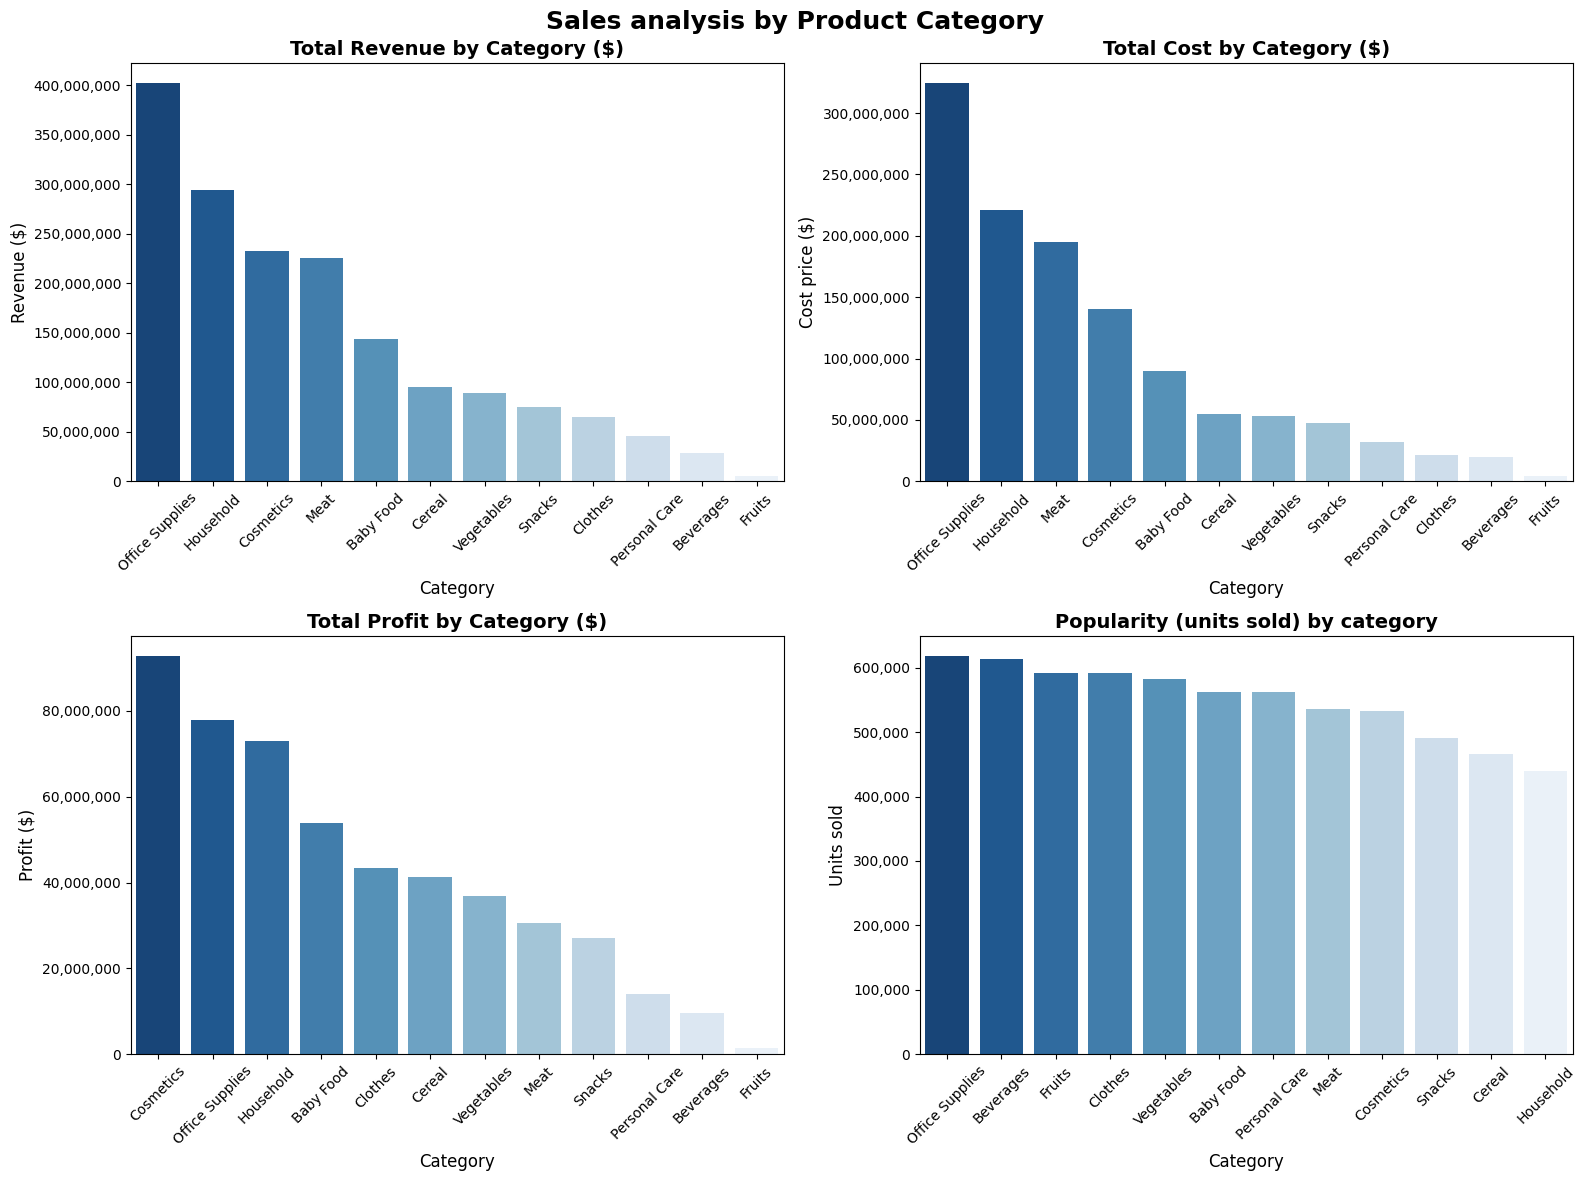

In [ ]:
# Setting the Montserrat font for all charts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Montserrat', 'DejaVu Sans', 'Arial']

# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sales analysis by Product Category", fontsize=18, fontweight="bold")

# Visualization of revenue by category
revenue_by_category = sales_data.groupby("category")["total_revenue"].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=revenue_by_category, x="category", y="total_revenue", hue="category", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Total Revenue by Category ($)", fontsize=14, fontweight="bold")
ax[0, 0].tick_params(axis="x", rotation=45)
ax[0, 0].set_xlabel("Category", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of cost by category
cost_by_category = sales_data.groupby("category")["total_cost"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cost_by_category, x="category", y="total_cost", hue="category", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Total Cost by Category ($)", fontsize=14, fontweight="bold")
ax[0, 1].tick_params(axis="x", rotation=45)
ax[0, 1].set_xlabel("Category", fontsize=12)
ax[0, 1].set_ylabel("Cost price ($)", fontsize=12)

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of profit by category
profit_by_category = sales_data.groupby("category")["total_profit"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=profit_by_category, x="category", y="total_profit", hue="category", errorbar=("ci", False), ax=ax[1, 0], palette="Blues_r")
ax[1, 0].set_title("Total Profit by Category ($)", fontsize=14, fontweight="bold")
ax[1, 0].tick_params(axis="x", rotation=45)
ax[1, 0].set_xlabel("Category", fontsize=12)
ax[1, 0].set_ylabel("Profit ($)", fontsize=12)

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of product category popularity
units_category = sales_data.groupby("category")["units_sold"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=units_category, x="category", y="units_sold", hue="category", errorbar=("ci", False), ax=ax[1, 1], palette="Blues_r")
ax[1, 1].set_title("Popularity (units sold) by category", fontsize=14, fontweight="bold")
ax[1, 1].tick_params(axis="x", rotation=45)
ax[1, 1].set_xlabel("Category", fontsize=12)
ax[1, 1].set_ylabel("Units sold", fontsize=12)

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

In [ ]:
# Calculation of the cost ratio
ratio = total_cost / total_revenue * 100
print(f"Ratio (total_cost / total_revenue): {ratio:.2f}")

Ratio (total_cost / total_revenue): 70.56


###**Conclusions**
####**Identified during an analysis of the total revenue graph:**

The *“Office Supplies”* and *"Household"* categories have the highest total revenue; *“Cosmetics”* ranks third (but ranks first in net profit). Overall, these three categories together account for a significant share of profits.

The *"Meat"*, *"Baby Food"*, and *"Cereal"* categories provide the company with stable and substantial revenue, contributing to the overall total. It’s also worth noting that the *"Cosmetics*" and *"Meat"* categories are close in terms of revenue, but the former ranks among the top three-which is why I separated them in my conclusions.

The least profitable categories are *"Beverages"* and *"Fruits"*. This suggests that they either have a relatively lower price or account for a small share of the company’s total sales. In this case, the data points to the former, since in terms of the number of units sold (popularity), both categories rank among the top three.

<br>

####**Identified during the analysis of the total cost graph:**
The expense chart closely mirrors the income table. The top categories, *“Office Supplies”* and *“Household”*, also require the largest expenditures, which makes sense.

A significant portion of the company's revenue goes toward covering the cost of goods (about 70% of total revenue), which indicates high costs associated with purchasing products.

The “Meat” category has a high cost of goods sold relative to its position on the profit chart. In my opinion, this warrants further analysis.

The categories with the lowest performance are *“Beverages”*, *“Fruit”*, and *“Clothing”* - they require the least expenditure, but they also generate the least profit for the company, with the exception of *“Clothing”*, which ranks 5th in the top 5 by profit

<br>

####**Identified during the analysis of the gross profit graph:**
The *“Cosmetics”* category ranks first in terms of profit, which indicates strong profitability relative to revenue or cost of goods sold.

*“Office Supplies”* and *“Household"* rank second and third. Thanks to their high sales volume, they generate significant profits. *“Office Supplies”* ranks first in popularity, while *“Household”* ranks last-even though they have sold about 170к units.

The *“Baby Food”*, *“Clothes”*, *“Cereal”*, and *“Vegetables”* categories generate a stable, moderate profit, but *"Beverages"* and *“Fruits”* yield the lowest net margins, even though they lead in unit sales due to their low cost.

<br>

####**Identified during the analysis of the units sold graph:**
The *“Office Supplies”* category ranks first in terms of units sold, which once again demonstrates its dominant role in all key aspects of the business (revenue, expenses, number of units).  Meanwhile, *“Household”* ranks last, which points to high prices - a factor that explains its leading position across all other financial metrics when broken down by category.

*“Beverages”* and *“Fruits”*, which ranked at the very bottom in terms of revenue and profit, are among the leaders in popularity. This clearly shows that they have high sales volumes in units, but their low price prevents them from generating significant financial income.

Categories such as *“Cosmetics”* and *“Baby Food”* show average sales figures in units but have high profit margins, as evidenced by their leading position in terms of profits

### **Recommendations**
It is worth continuing to invest in key categories (*"Office Supplies"* and *"Household"*), as they account for the bulk of the company’s revenue and profit.

Since the *“Cosmetics”* category ranks first in terms of profit despite relatively low overall sales volumes, it is worth considering expanding the product range in this area or implementing additional marketing initiatives to increase its share of total revenue.

The *“Beverages”* and *“Fruits”* categories are very popular but generate minimal profit due to their low prices. It is worth reviewing pricing or optimizing logistics and procurement costs to improve their profitability.

It is also worth paying attention to the *“Meat”* category, which accounts for a significant portion of the cost of goods sold relative to its share of profit, and implementing certain optimizations.

## **Sales analysis by countries**

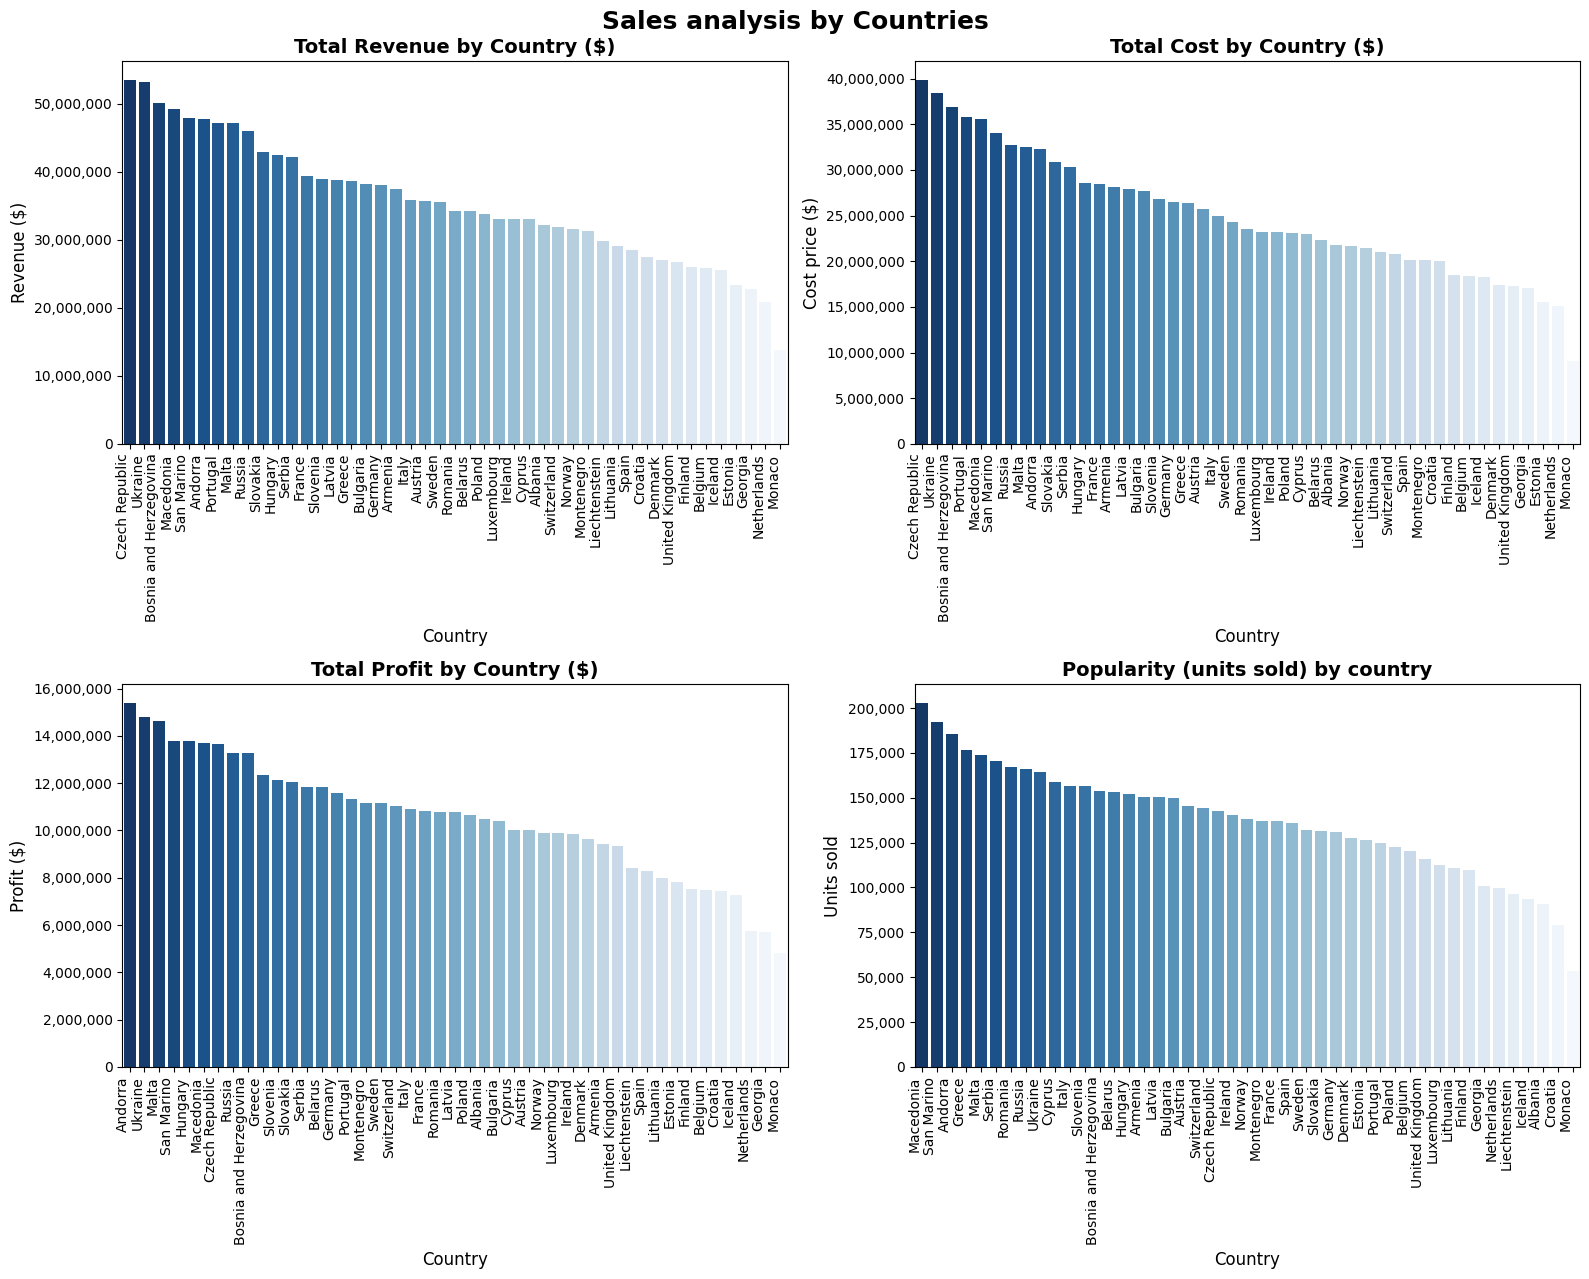

In [ ]:
# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Sales analysis by Countries", fontsize=18, fontweight="bold")

# Visualization of revenue by countries
revenue_by_country = sales_data.groupby("country")["total_revenue"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=revenue_by_country, x="country", y="total_revenue", hue="country", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Total Revenue by Country ($)", fontsize=14, fontweight="bold")
ax[0, 0].tick_params(axis="x", rotation=90, labelsize=10)
ax[0, 0].set_xticks(range(len(revenue_by_country)))
ax[0, 0].set_xticklabels(ax[0, 0].get_xticklabels(), ha='right')
ax[0, 0].set_xlabel("Country", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of cost by countries
cost_by_country = sales_data.groupby("country")["total_cost"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cost_by_country, x="country", y="total_cost", hue="country", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Total Cost by Country ($)", fontsize=14, fontweight="bold")
ax[0, 1].tick_params(axis="x", rotation=90, labelsize=10)
ax[0, 1].set_xticks(range(len(cost_by_country)))
ax[0, 1].set_xticklabels(ax[0, 1].get_xticklabels(), ha='right')
ax[0, 1].set_xlabel("Country", fontsize=12)
ax[0, 1].set_ylabel("Cost price ($)", fontsize=12)

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of profit by countries
profit_by_country = sales_data.groupby("country")["total_profit"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=profit_by_country, x="country", y="total_profit", hue="country", errorbar=("ci", False), ax=ax[1, 0], palette="Blues_r")
ax[1, 0].set_title("Total Profit by Country ($)", fontsize=14, fontweight="bold")
ax[1, 0].tick_params(axis="x", rotation=90, labelsize=10)
ax[1, 0].set_xticks(range(len(profit_by_country)))
ax[1, 0].set_xticklabels(ax[1, 0].get_xticklabels(), ha='right')
ax[1, 0].set_xlabel("Country", fontsize=12)
ax[1, 0].set_ylabel("Profit ($)", fontsize=12)

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of the number of units sold by country
units_country = sales_data.groupby("country")["units_sold"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=units_country, x="country", y="units_sold", hue="country", errorbar=("ci", False), ax=ax[1, 1], palette="Blues_r")
ax[1, 1].set_title("Popularity (units sold) by country", fontsize=14, fontweight="bold")
ax[1, 1].tick_params(axis="x", rotation=90, labelsize=10)
ax[1, 1].set_xticks(range(len(units_country)))
ax[1, 1].set_xticklabels(ax[1, 1].get_xticklabels(), ha='right')
ax[1, 1].set_xlabel("Country", fontsize=12)
ax[1, 1].set_ylabel("Units sold", fontsize=12)

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions**
####**Identified during an analysis of the total revenue graph:**
The top spots in terms of total revenue are held by the *Czech Republic* (first place) and *Ukraine* (second). They account for the largest share of the company’s revenue among all 45 markets. *Bosnia and Herzegovina* comes in third, trailing by a narrow margin.

Next comes a large group of countries in the middle (such as *Macedonia*, *San Marino*, *Andorra*, *Portugal*, etc.); they show very similar, smooth revenue trends and together form a steady downward trend without any sharp spikes. Also, looking ahead, some countries in this group lead in terms of profit (*Andorra*, *San Marino*).

The graph shows a smooth distribution, with most countries contributing a stable average or lower share to the company's total revenue, gradually decreasing toward the end of the list (less active markets, such as *Georgia*, *the Netherlands*, and *Monaco* - countries listed in descending order at the very end).

<br>

####**Identified during the analysis of the total cost graph:**
The Total Cost chart closely mirrors the trends shown in the Total Revenue chart. The countries with the highest expenses are the same - *the Czech Republic* and *Ukraine*, followed by *Bosnia and Herzegovina* in third place, which makes sense: the highest revenue requires the highest expenses.

The cost chart shows once again that the cost of goods represents about 70% of total revenue.

Similar to revenue, after the leaders there is a steady, gradual decline in costs among the same middle group of countries (*Andorra*, *San Marino*, *Portugal*, etc.), with the lowest costs at the bottom of the list (markets such as *Estonia*, *the Netherlands*, and *Monaco* - listed in descending order at the very end), which once again demonstrates the correlation between revenue and the cost of goods.

<br>

####**Identified during the analysis of the gross profit graph:**
Unlike the revenue and cost charts, where the *Czech Republic*, *Ukraine*, and *Bosnia and Herzegovina* ranked at the top, the profit ranking looks slightly different. Some markets from the middle group (for example, *Andorra* (1st in terms of profit), *Malta* (3rd), or *San Marino* (4th)) show high profitability. But it’s also worth noting that Ukraine has remained in the top two, in 2nd place.

The *Netherlands*, *Georgia*, and *Monaco* remain the least profitable countries (always at the very bottom). While this situation for *Monaco* can be attributed to the country’s small size, the *Netherlands* raises more questions, a more in-depth analysis is warranted.

<br>

####**Identified during the analysis of the units sold graph:**

In terms of the number of units sold, *Ukraine*, which leads in other financial indicators has shifted closer to the middle of the chart, indicating a high price per unit rather than high sales volume. I’d also like to draw attention to the *Czech Republic*, since, as seen in previous charts, it has high revenue and cost of goods sold, but significantly lower profit and here, too, it has shifted toward the middle of the chart. Revenue comes from price, not volume, and the high cost of goods sold is eating into the margin.

Countries such as *Macedonia*, *San Marino*, and *Andorra* rank first in terms of the number of units sold. *Macedonia* has consistently ranked 4th to 6th in all previous charts, indicating an average selling price and high popularity. As for the other two countries, they lead in profit (*Andorra* in first place, *San Marino* in fourth) and are among the top three in sales volume these are the strongest markets.

The bottom three (with the fewest items sold) included new countries such as *Albania* (which was mostly in the middle in previous charts) and *Croatia* (which was closer to the bottom).  This indicates a relatively high price in *Albania*, but lower sales volumes. As for *Croatia*, the ratio is generally low. *Monaco* remains the least popular.


### **Recommendations**
Markets such as *Andorra* and *San Marino* are showing strong results in terms of profitability and high sales volumes, with average costs. It would be worthwhile to conduct a more detailed analysis of these countries, familiarize ourselves with their products and marketing activities, in order to replicate this success in other mid-sized markets.

The *Czech Republic* generates the highest revenue, but high cost of goods significantly erodes profit. We need to review the factors influencing this and, where possible, optimize them to increase the conversion of revenue into profit.

The *Netherlands* is underperforming compared to other countries, so it is worth conducting a more in-depth analysis of the reasons behind its weak profitability and sales

Markets at the bottom of the charts (such as *Monaco*, *Albania*, or *Croatia*, with the fewest units sold) require a review of marketing efforts to increase brand awareness or a reallocation of the budget to more profitable markets. *Monaco* and *Croatia* fall into the latter category, as they are small countries and no significant trends are apparent. *Albania*, on the other hand, has a high price and low volume; it’s worth considering the first option.

## **Sales analysis by sub-regions**

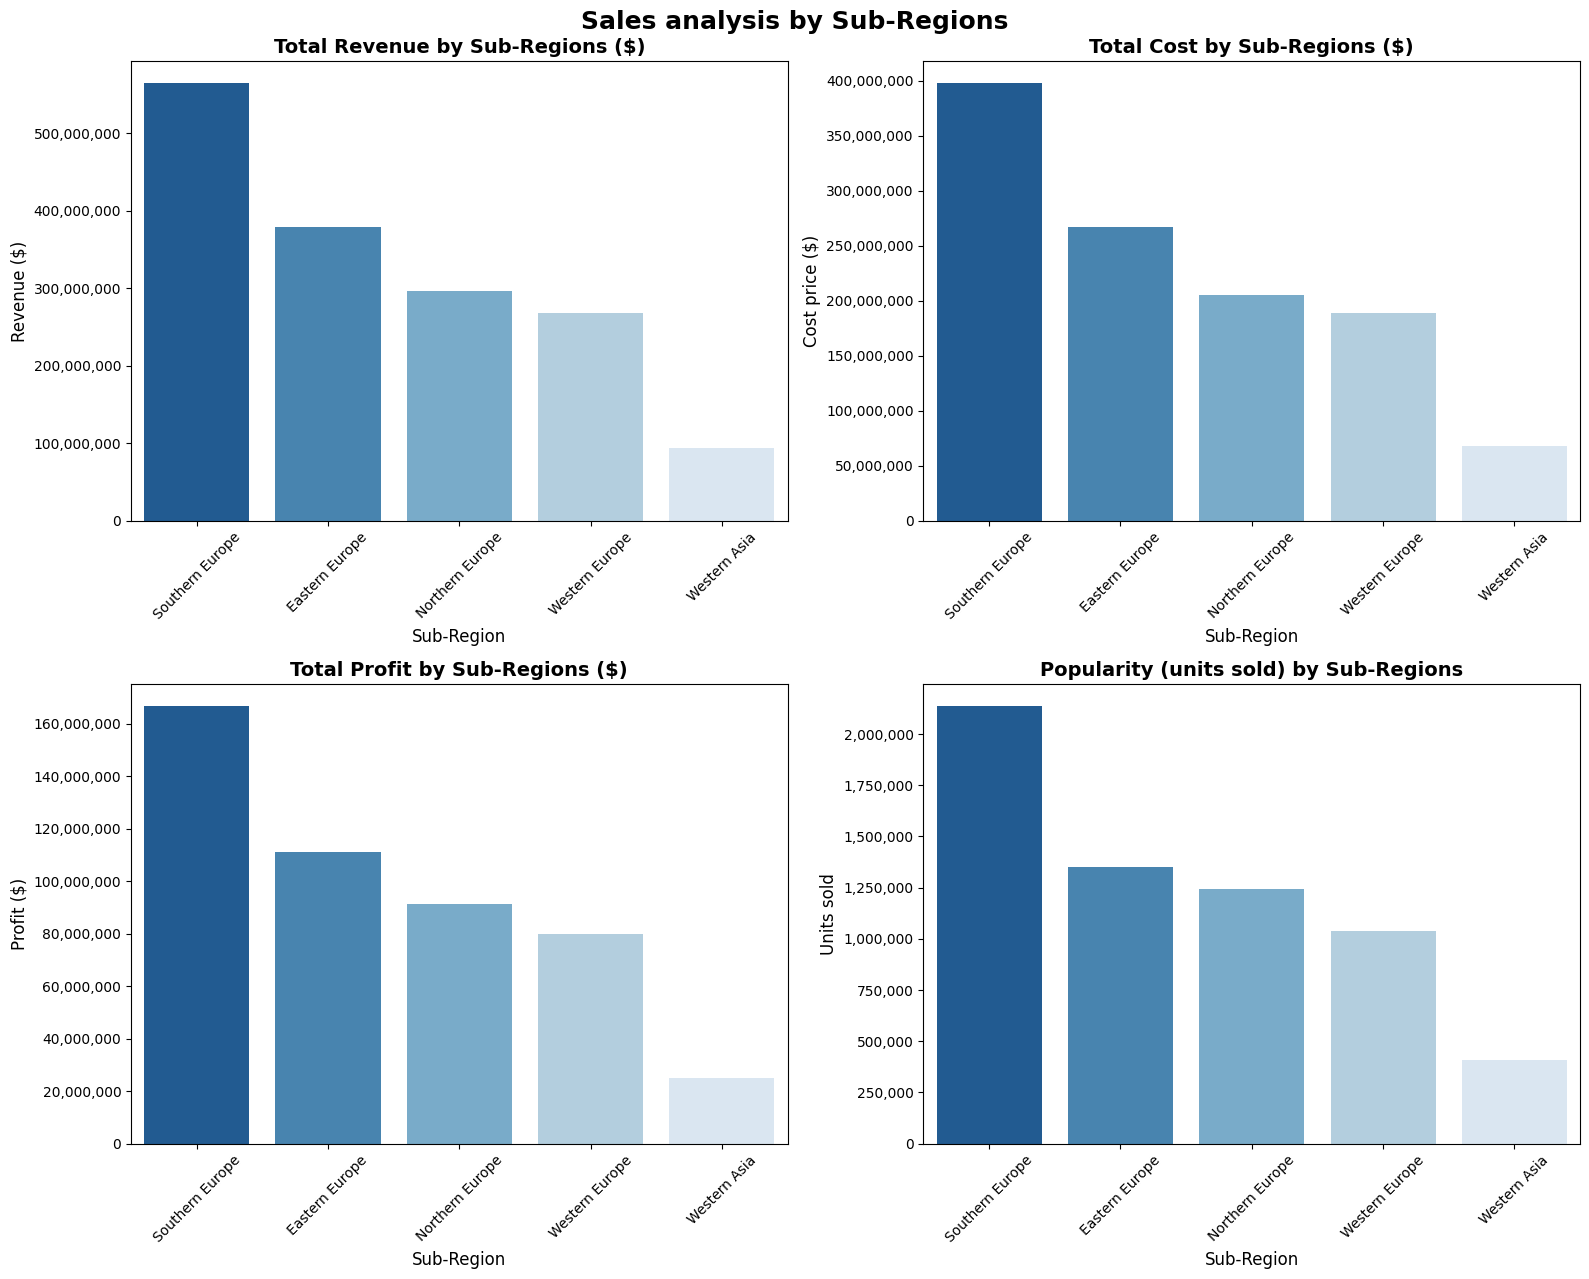

In [ ]:
# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Sales analysis by Sub-Regions", fontsize=18, fontweight="bold")

# Visualization of revenue by sub-regions
revenue_by_region = sales_data.groupby("sub_region")["total_revenue"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=revenue_by_region, x="sub_region", y="total_revenue", hue="sub_region", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Total Revenue by Sub-Regions ($)", fontsize=14, fontweight="bold")
ax[0, 0].tick_params(axis="x", rotation=45)
ax[0, 0].set_xlabel("Sub-Region", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of cost by sub-regions
cost_by_region = sales_data.groupby("sub_region")["total_cost"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cost_by_region, x="sub_region", y="total_cost", hue="sub_region", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Total Cost by Sub-Regions ($)", fontsize=14, fontweight="bold")
ax[0, 1].tick_params(axis="x", rotation=45)
ax[0, 1].set_xlabel("Sub-Region", fontsize=12)
ax[0, 1].set_ylabel("Cost price ($)", fontsize=12)

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of profit by sub-regions
profit_by_region = sales_data.groupby("sub_region")["total_profit"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=profit_by_region, x="sub_region", y="total_profit", hue="sub_region", errorbar=("ci", False), ax=ax[1, 0], palette="Blues_r")
ax[1, 0].set_title("Total Profit by Sub-Regions ($)", fontsize=14, fontweight="bold")
ax[1, 0].tick_params(axis="x", rotation=45)
ax[1, 0].set_xlabel("Sub-Region", fontsize=12)
ax[1, 0].set_ylabel("Profit ($)", fontsize=12)

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of the number of units sold by sub-regions
units_region = sales_data.groupby("sub_region")["units_sold"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=units_region, x="sub_region", y="units_sold", hue="sub_region", errorbar=("ci", False), ax=ax[1, 1], palette="Blues_r")
ax[1, 1].set_title("Popularity (units sold) by Sub-Regions", fontsize=14, fontweight="bold")
ax[1, 1].tick_params(axis="x", rotation=45)
ax[1, 1].set_xlabel("Sub-Region", fontsize=12)
ax[1, 1].set_ylabel("Units sold", fontsize=12)

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions**
At the subregional level, the graphs show the same pattern: *Southern Europe* ranks first, while *Western Asia* ranks last (by a wide margin). No region stands out significantly; this can be explained by the fact that countries with high and low scores are grouped together, which smooths out the differences.

##**Sales analysis by sales channel**

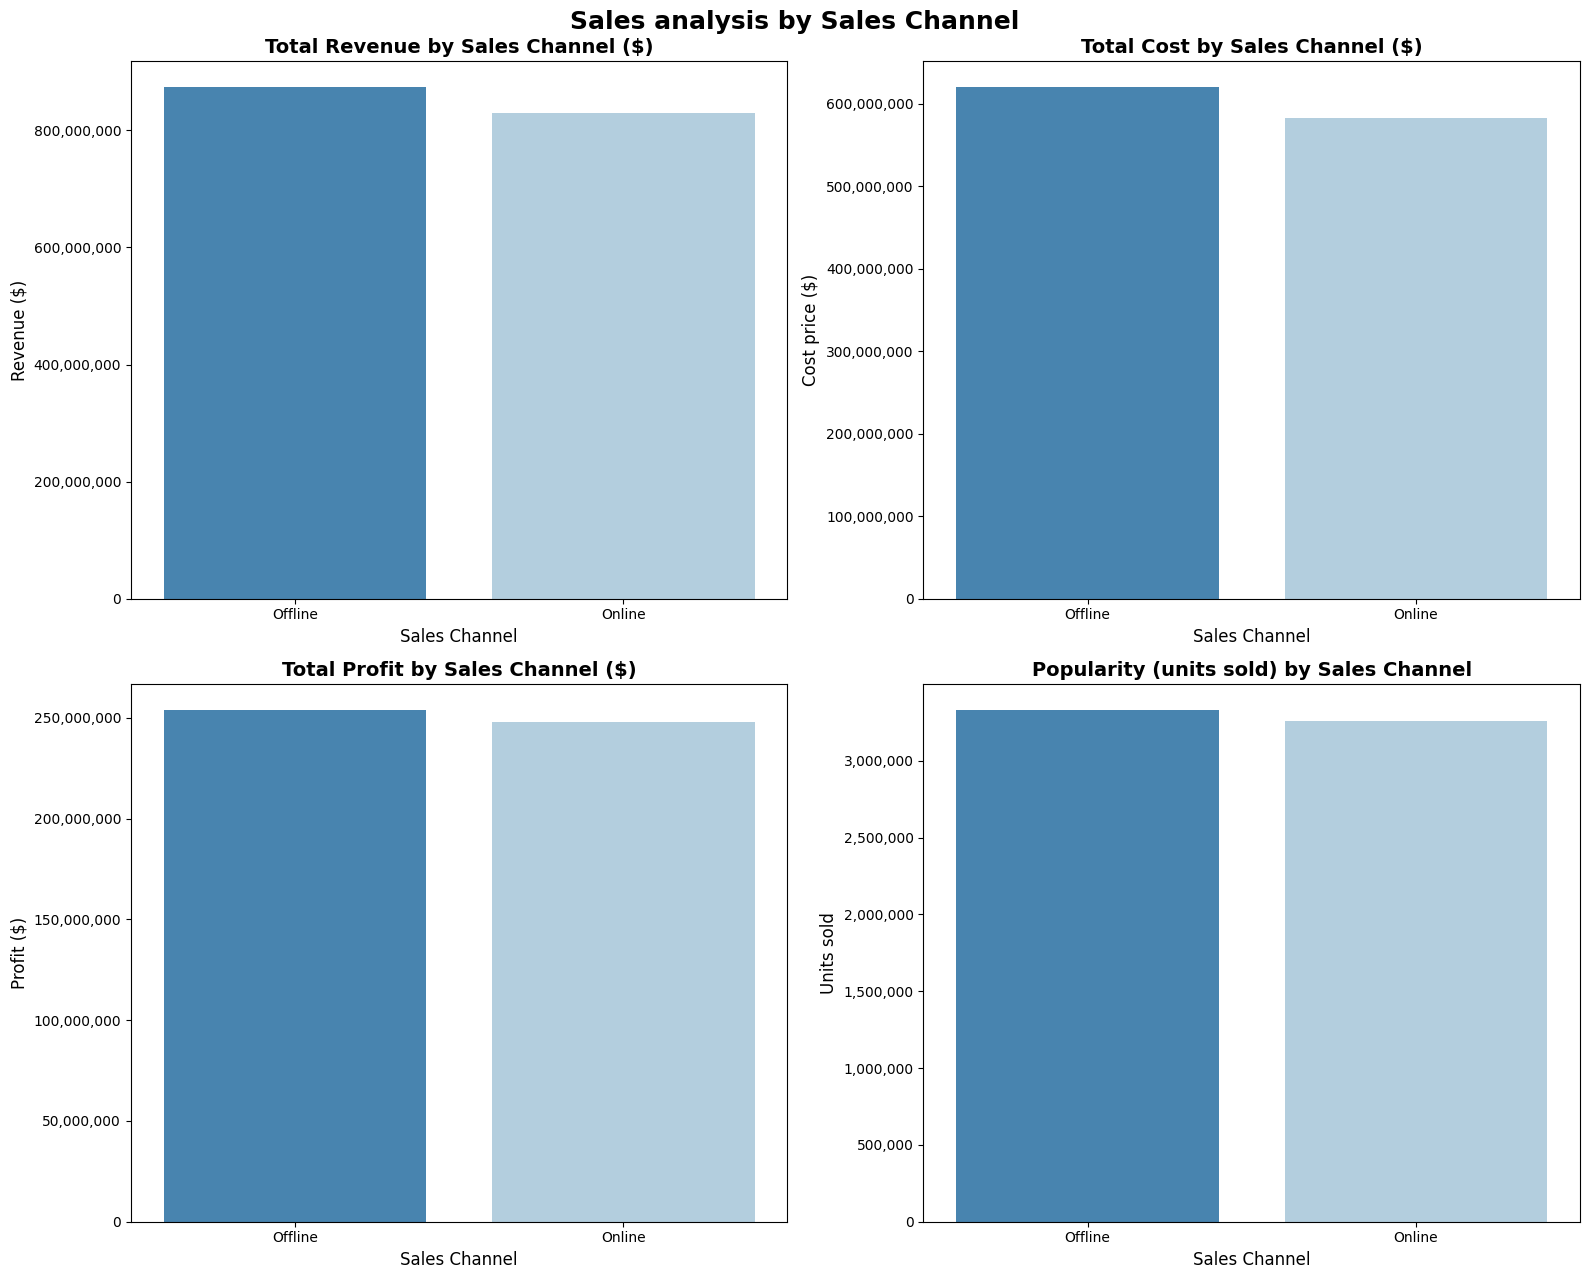

In [ ]:
# Creating an array for charts
sales_data["sales_channel"] = sales_data["sales_channel"].str.strip().str.capitalize()
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Sales analysis by Sales Channel", fontsize=18, fontweight="bold")

# Visualization of revenue by sales channel
revenue_by_channel = sales_data.groupby("sales_channel")["total_revenue"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=revenue_by_channel, x="sales_channel", y="total_revenue", hue="sales_channel", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Total Revenue by Sales Channel ($)", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Sales Channel", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of cost by sales channel
cost_by_channel = sales_data.groupby("sales_channel")["total_cost"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cost_by_channel, x="sales_channel", y="total_cost", hue="sales_channel", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Total Cost by Sales Channel ($)", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Sales Channel", fontsize=12)
ax[0, 1].set_ylabel("Cost price ($)", fontsize=12)

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of profit by sales channel
profit_by_channel = sales_data.groupby("sales_channel")["total_profit"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=profit_by_channel, x="sales_channel", y="total_profit", hue="sales_channel", errorbar=("ci", False), ax=ax[1, 0], palette="Blues_r")
ax[1, 0].set_title("Total Profit by Sales Channel ($)", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Sales Channel", fontsize=12)
ax[1, 0].set_ylabel("Profit ($)", fontsize=12)

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of the number of units sold by sales channel
units_channel = sales_data.groupby("sales_channel")["units_sold"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=units_channel, x="sales_channel", y="units_sold", hue="sales_channel", errorbar=("ci", False), ax=ax[1, 1], palette="Blues_r")
ax[1, 1].set_title("Popularity (units sold) by Sales Channel", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Sales Channel", fontsize=12)
ax[1, 1].set_ylabel("Units sold", fontsize=12)

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions**
*Offline* purchases lead the way in all four charts, although *online* purchases aren't far behind. The business isn't reliant on a single channel, which is a positive sign.

##**Shipping time analysis**

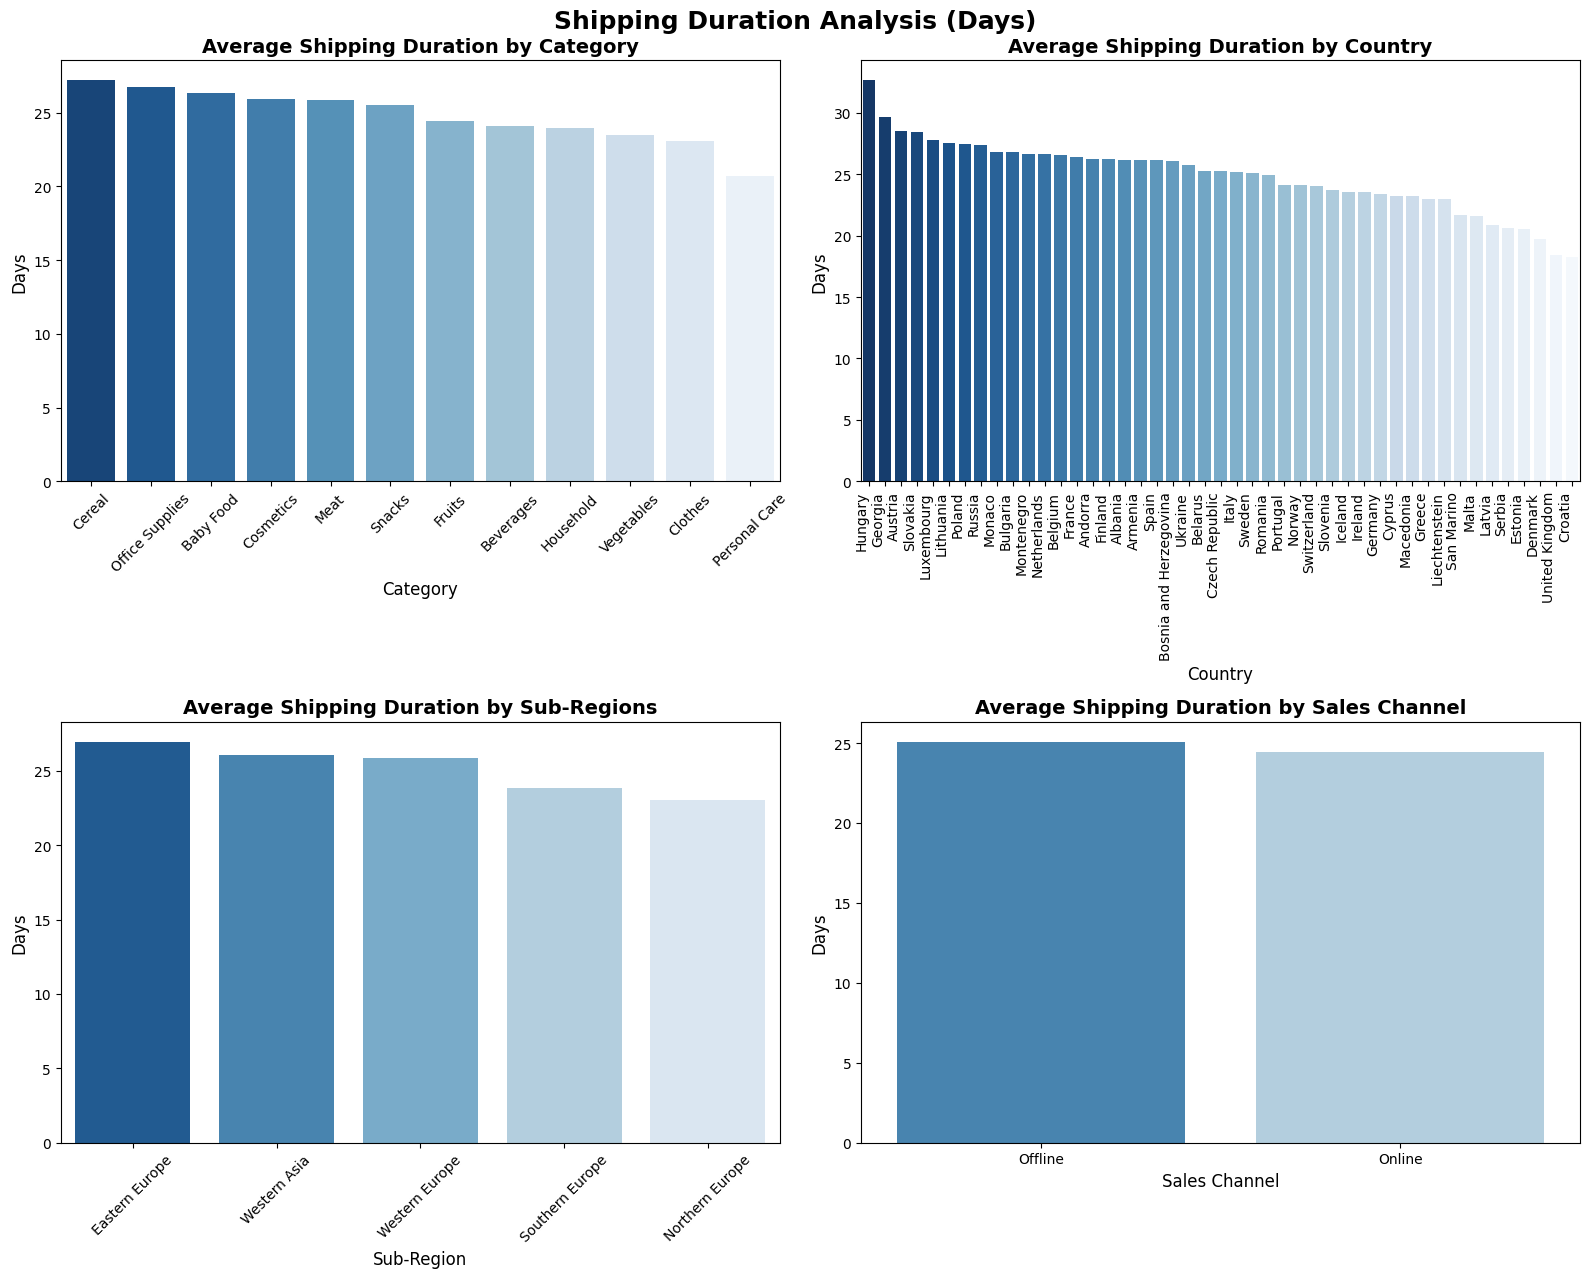

In [ ]:
# Calculating the time interval between order placement and shipment (in days)
shipping_duration = sales_data["ship_date"] - sales_data["order_date"]
sales_data["shipping_duration"] = shipping_duration.dt.days

# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Shipping Duration Analysis (Days)", fontsize=18, fontweight="bold")

# Calculation and visualization of average delivery times by category
duration_by_category = sales_data.groupby("category")["shipping_duration"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=duration_by_category, x="category", y="shipping_duration", hue="category", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Average Shipping Duration by Category", fontsize=14, fontweight="bold")
ax[0, 0].tick_params(axis="x", rotation=45)
ax[0, 0].set_xlabel("Category", fontsize=12)
ax[0, 0].set_ylabel("Days", fontsize=12)

# Calculation and visualization of average delivery times by country
duration_by_country = sales_data.groupby("country")["shipping_duration"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=duration_by_country, x="country", y="shipping_duration", hue="country", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Average Shipping Duration by Country", fontsize=14, fontweight="bold")
ax[0, 1].tick_params(axis="x", rotation=90, labelsize=10)
ax[0, 1].set_xticks(range(len(duration_by_country)))
ax[0, 1].set_xticklabels(ax[0, 1].get_xticklabels(), ha='right')
ax[0, 1].set_xlabel("Country", fontsize=12)
ax[0, 1].set_ylabel("Days", fontsize=12)

# Calculation and visualization of average delivery times by sub-regions
duration_by_region = sales_data.groupby("sub_region")["shipping_duration"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=duration_by_region, x="sub_region", y="shipping_duration", hue="sub_region", errorbar=("ci", False), ax=ax[1, 0], palette="Blues_r")
ax[1, 0].set_title("Average Shipping Duration by Sub-Regions", fontsize=14, fontweight="bold")
ax[1, 0].tick_params(axis="x", rotation=45)
ax[1, 0].set_xlabel("Sub-Region", fontsize=12)
ax[1, 0].set_ylabel("Days", fontsize=12)

# Calculation and visualization of average delivery times by sales channel
duration_by_channel = sales_data.groupby("sales_channel")["shipping_duration"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=duration_by_channel, x="sales_channel", y="shipping_duration", hue="sales_channel", errorbar=("ci", False), ax=ax[1, 1], palette="Blues_r")
ax[1, 1].set_title("Average Shipping Duration by Sales Channel", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Sales Channel", fontsize=12)
ax[1, 1].set_ylabel("Days", fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions and Recommendations**
The average delivery time is generally between *20 and 27 days*. The differences between categories, countries, channels, and regions are negligible

However, the delivery time itself is very long, so it’s worth paying attention to logistics and conducting a more in-depth analysis to further optimize this factor. For example, it’s generally expected that online orders should be delivered faster than offline ones—but the data doesn’t show this; the difference is half a day to a full day.

There is also a difference across categories - *“Personal Care”* is delivered the fastest, while *“Cereal”* is the slowest. In this situation, it’s best to first address the delivery time itself and then move on to the categories.

*Northern Europe* delivers goods the fastest, while *Eastern Europe* delivers them the slowest. The difference of 2–3 days isn't very significant.

The most profitable countries - *Andorra*, *Ukraine* and *Malta* have relatively average delivery times.

*Croatia* has the longest delivery times.

##**Analysis of the relationship between profit and delivery time**

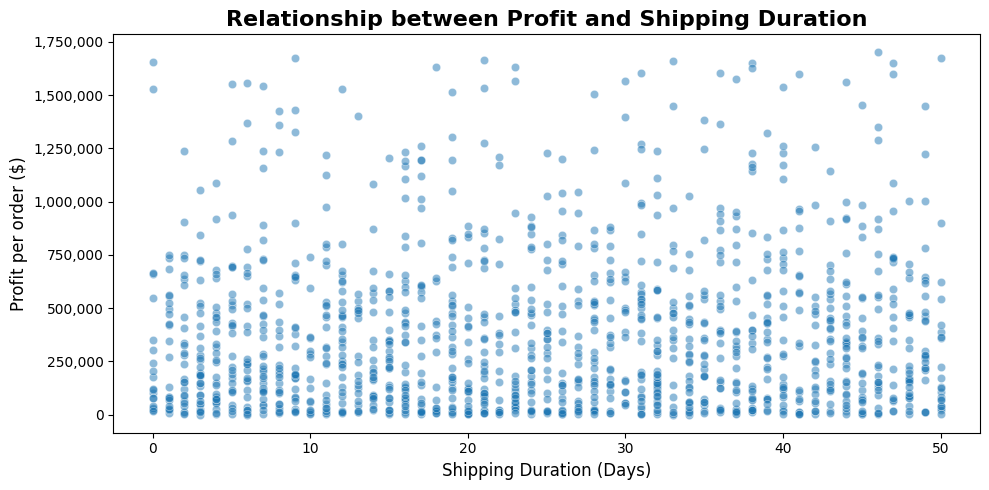

In [ ]:
# Visualization of the relationship between profit and delivery time
plt.figure(figsize=(10,5))
sns.scatterplot(data=sales_data, x="shipping_duration", y="total_profit", alpha=0.5, color="#1f77b4")
plt.title("Relationship between Profit and Shipping Duration", fontsize=16, fontweight="bold")
plt.xlabel("Shipping Duration (Days)", fontsize=12)
plt.ylabel("Profit per order ($)", fontsize=12)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions**
*The graph clearly shows that profit does not depend on delivery time.* The data points form uniform vertical lines at each duration value; there is neither an increase nor a decrease, indicating a lack of correlation.

Profit depends on the price and cost of goods, while delivery time has no effect.

##**Analysis of Sales Trends Over Time**

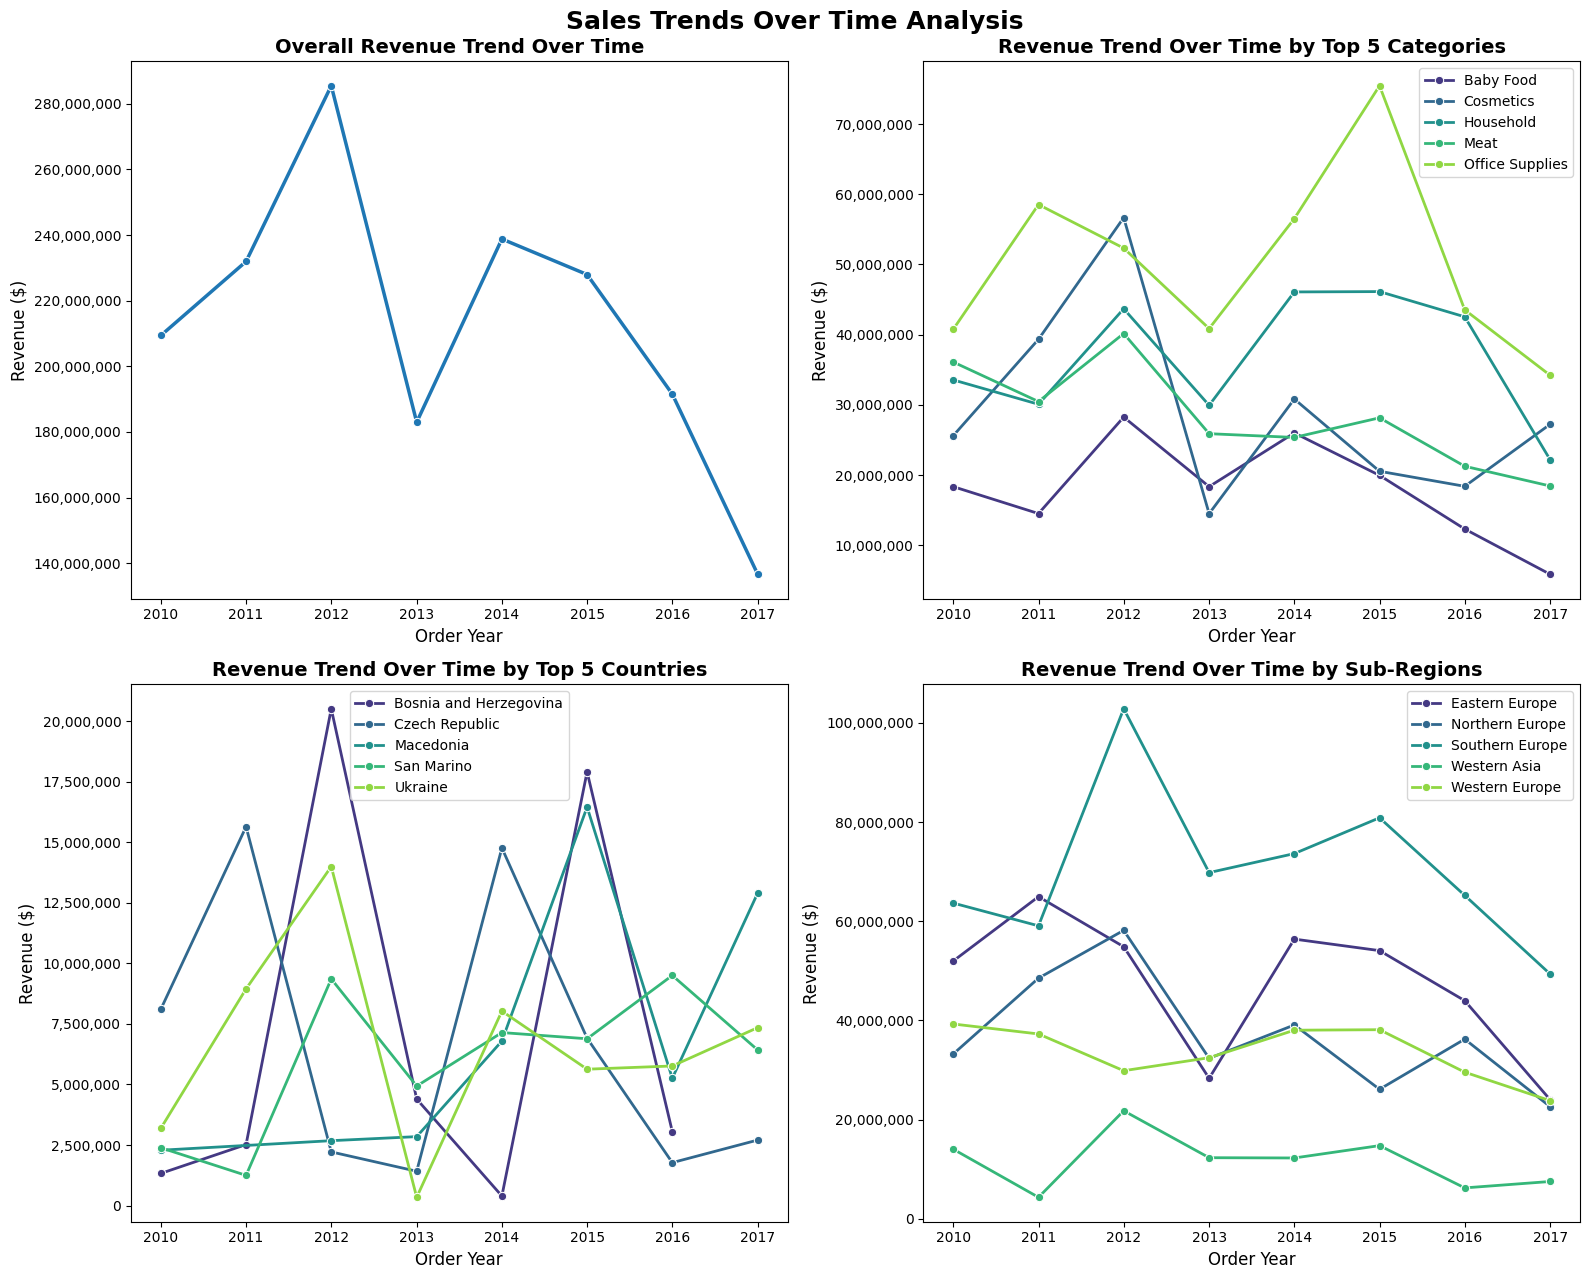

In [ ]:
# Creating a column with the order period (by year)
sales_data["order_year"] = sales_data["order_date"].dt.to_period("Y").dt.to_timestamp()

# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Sales Trends Over Time Analysis", fontsize=18, fontweight="bold")

# Visualization of overall revenue trends over time
yearly_revenue = sales_data.groupby("order_year")["total_revenue"].sum().reset_index()
sns.lineplot(data=yearly_revenue, x="order_year", y="total_revenue", ax=ax[0, 0], linewidth=2.5, color="#1f77b4", marker="o")
ax[0, 0].set_title("Overall Revenue Trend Over Time", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Order Year", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of revenue trends by the top 5 product categories
top_5_categories = sales_data.groupby("category")["total_revenue"].sum().nlargest(5).index
yearly_top_categories = sales_data[sales_data["category"].isin(top_5_categories)].groupby(["order_year", "category"])["total_revenue"].sum().reset_index()

sns.lineplot(data=yearly_top_categories, x="order_year", y="total_revenue", hue="category", ax=ax[0, 1], linewidth=2, palette="viridis", marker="o")
ax[0, 1].set_title("Revenue Trend Over Time by Top 5 Categories", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Order Year", fontsize=12)
ax[0, 1].set_ylabel("Revenue ($)", fontsize=12)
ax[0, 1].legend()

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of revenue trends by the top 5 countries
top_5_countries = sales_data.groupby("country")["total_revenue"].sum().nlargest(5).index
yearly_top_countries = sales_data[sales_data["country"].isin(top_5_countries)].groupby(["order_year", "country"])["total_revenue"].sum().reset_index()

sns.lineplot(data=yearly_top_countries, x="order_year", y="total_revenue", hue="country", ax=ax[1, 0], linewidth=2, palette="viridis", marker="o")
ax[1, 0].set_title("Revenue Trend Over Time by Top 5 Countries", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Order Year", fontsize=12)
ax[1, 0].set_ylabel("Revenue ($)", fontsize=12)
ax[1, 0].legend()

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of revenue trends by sub-regions
yearly_by_subregion = sales_data.groupby(["order_year", "sub_region"])["total_revenue"].sum().reset_index()
sns.lineplot(data=yearly_by_subregion, x="order_year", y="total_revenue", hue="sub_region", ax=ax[1, 1], linewidth=2, palette="viridis", marker="o")
ax[1, 1].set_title("Revenue Trend Over Time by Sub-Regions", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Order Year", fontsize=12)
ax[1, 1].set_ylabel("Revenue ($)", fontsize=12)
ax[1, 1].legend()

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

In [ ]:
# Data completeness check
print(sales_data["order_year"].dt.year.value_counts().sort_index())

order_year
2010    166
2011    175
2012    202
2013    158
2014    188
2015    160
2016    175
2017    106
Name: count, dtype: int64


###**Conclusions**
####**Identified during an analysis of the overall annual revenue trend graph:**

*The graph does not show any stability in revenue.* From 2010 to 2012 (\~*285M* - the peak for all years in the analysis), the company’s revenue grew, followed by a sharp decline through 2013 (\~*183M*), after which it rose again through 2014 (\~*238M*). Then there was another decline, but a gradual one, through 2017 (the lowest point, \~*137M*).

The business peaked in revenue in 2012 and has been consistently losing money since 2014.

2017 has the lowest figures of all eight years analyzed, but it’s also worth noting that the data in the dataset for that year is incomplete, covering only the period up to July 23, 2017. Therefore, it would not be accurate to compare it with complete data.

<br>

####**Identified during an analysis of the revenue trend over years by top 5 categories:**

The *“Office Supplies”* category has shown the highest figures almost all the time, peaking in 2015 (\~*76M*). However, there are also constant fluctuations; it is not stable, and it has been on a downward trend since 2017.

The *“Baby Food”* category had two peaks of its own in 2012 (\~*28M*) and 2014 (\~*25M*), but has been on a downward trend since 2012. In 2017, it reached the lowest figure among the five categories analyzed: ~6M

The *“Cosmetics”* category fluctuates the most between growth and decline, peaking in 2012 (\~*57M*), falling in 2013 (\~*15M*), and then rising again. It is difficult to identify a clear trend.

The *“Household”* and *“Meat”* categories followed virtually identical trends through 2013, and since then have shown similar trends, though “Household” has higher figures. Overall, both peaked in 2012 (*“Household”*: \~*44M*, *“Meat”*: \~*41M*) and then declined through 2017.

Overall, a similar pattern can be observed across all categories: a peak in 2012 and a sharp decline in 2013, followed by renewed growth and a gradual decline through 2017 (though it’s worth noting again that the data for that year is incomplete).

<br>

####**Identified during an analysis of the revenue trend over years by top 5 countries:**

*At the country level, the trend is unstable: there is no common pattern, nor are there any consistent leaders.* The only exception is *Bosnia and Herzegovina*, which saw peaks in 2012 and 2015 and a sharp decline in between. This volatility may indicate a reliance on individual large orders rather than steady demand, especially when compared to subregions where aggregation smooths out these fluctuations. The decline in 2017 is, again, partly due to incomplete data.

<br>

####**Identified during an analysis of the revenue trend over years by sub-regions:**

At the subregional level, the trend is more stable than at the national level. *Southern Europe* has been the clear leader throughout the entire time period, with a significant lead and a peak in 2012 (\~*103M*). Moreover, even with a decline through 2017, it still remains among the top performers.

*Western Asia* consistently has the lowest figures (\~*10-20M* throughout the entire period) and follows a downward trend, just like all other subregions.

Here, too, there is a pattern of a peak in 2012 and a decline in 2013

### **Recommendations**
Revenue has been steadily declining from 2014 to 2016 (2017 is excluded as an incomplete year). The reason is not clear from the data available for analysis, so it is worth conducting a more in-depth study to identify the factors behind this trend before taking any action.

The Baby Food category shows the most sustained decline among the top 5. It is worth analyzing all factors and, based on the findings, taking action: either boosting demand through marketing or gradually phasing the product out of the product line.



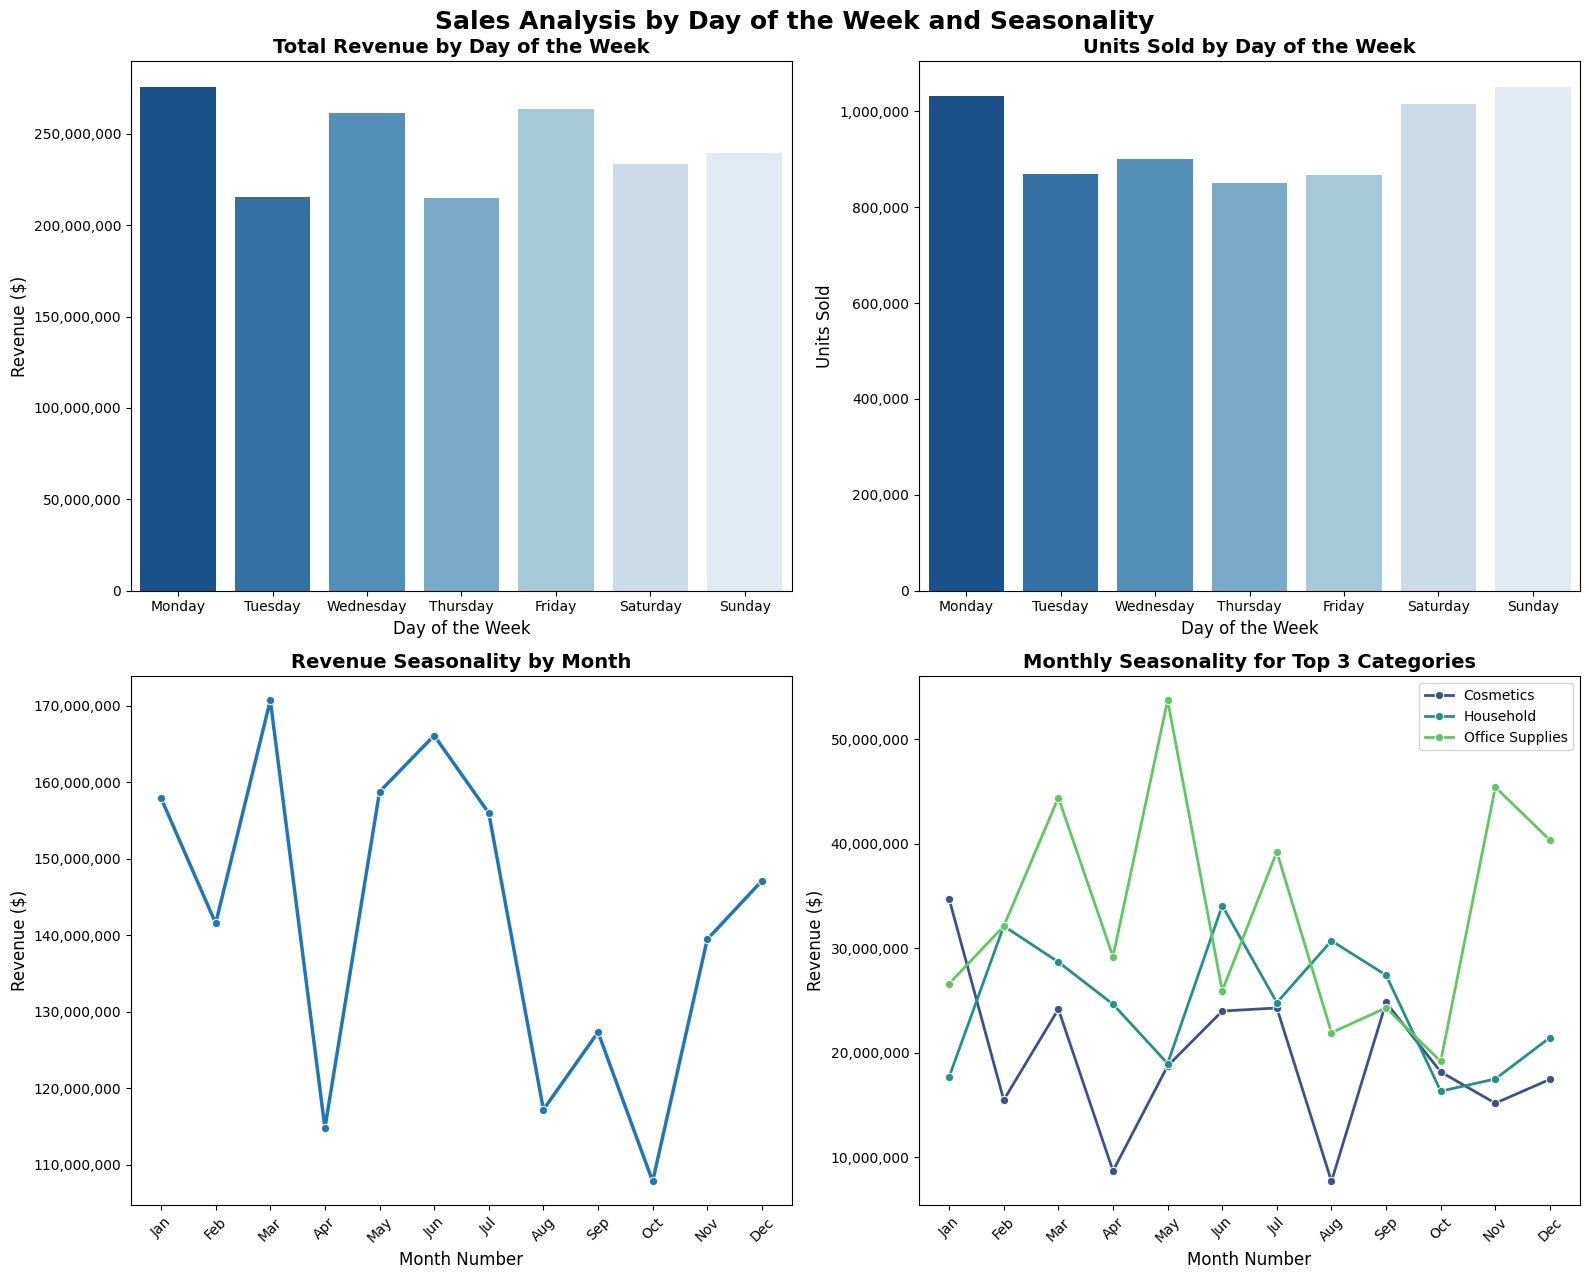

In [ ]:
# Creating the names of the days of the week and the month number
sales_data["order_day_of_week"] = sales_data["order_date"].dt.day_name()
sales_data["order_month_num"] = sales_data["order_date"].dt.month

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Creating an array for charts
fig, ax = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("Sales Analysis by Day of the Week and Seasonality", fontsize=18, fontweight="bold")

# List of days of the week
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Visualization of revenue by day of the week
daily_revenue = sales_data.groupby("order_day_of_week")["total_revenue"].sum().reindex(days_order).reset_index()
sns.barplot(data=daily_revenue, x="order_day_of_week", y="total_revenue", hue="order_day_of_week", errorbar=("ci", False), ax=ax[0, 0], palette="Blues_r")
ax[0, 0].set_title("Total Revenue by Day of the Week", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Day of the Week", fontsize=12)
ax[0, 0].set_ylabel("Revenue ($)", fontsize=12)

ax[0, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of units sold by day of the week
daily_units = sales_data.groupby("order_day_of_week")["units_sold"].sum().reindex(days_order).reset_index()
sns.barplot(data=daily_units, x="order_day_of_week", y="units_sold", hue="order_day_of_week", errorbar=("ci", False), ax=ax[0, 1], palette="Blues_r")
ax[0, 1].set_title("Units Sold by Day of the Week", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Day of the Week", fontsize=12)
ax[0, 1].set_ylabel("Units Sold", fontsize=12)

ax[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of revenue by month of the year
monthly_seasonality = sales_data.groupby("order_month_num")["total_revenue"].sum().reset_index()
sns.lineplot(data=monthly_seasonality, x="order_month_num", y="total_revenue", ax=ax[1, 0], linewidth=2.5, color="#1f77b4", marker="o")
ax[1, 0].set_title("Revenue Seasonality by Month", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Month Number", fontsize=12)
ax[1, 0].set_ylabel("Revenue ($)", fontsize=12)
ax[1, 0].set_xticks(range(1, 13))
ax[1, 0].set_xticklabels(month_names, rotation=45)

ax[1, 0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Visualization of revenue by month of the year, broken down by the top 3 categories
top_3_categories = sales_data.groupby("category")["total_revenue"].sum().nlargest(3).index
monthly_cat_seasonality = sales_data[sales_data["category"].isin(top_3_categories)].groupby(["order_month_num", "category"])["total_revenue"].sum().reset_index()
sns.lineplot(data=monthly_cat_seasonality, x="order_month_num", y="total_revenue", hue="category", ax=ax[1, 1], linewidth=2, palette="viridis", marker="o")
ax[1, 1].set_title("Monthly Seasonality for Top 3 Categories", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Month Number", fontsize=12)
ax[1, 1].set_ylabel("Revenue ($)", fontsize=12)
ax[1, 1].set_xticks(range(1, 13))
ax[1, 1].set_xticklabels(month_names, rotation=45)
ax[1, 1].legend()

ax[1, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

###**Conclusions**
The distribution of sales by day of the week is fairly even, with both revenue and quantity remaining at similar levels across all seven days. *Monday*, *Wednesday*, and *Friday* see slightly higher revenue, while *Sunday* and *Monday* lead in the number of units sold, though the difference is negligible. Based on the data, we can conclude that orders are not tied to the workweek.

As for seasonality, there are no clearly seasonal products. However, the monthly charts show fluctuations: *peaks in March and June and dips in April, August, and October.* The top three categories (*"Office Supplies", "Household", "Cosmetics"*) fluctuate from month to month, but this is more a matter of volatility than seasonality.